# Лабораторная работа № 1.4 — Метод вращений Якоби

Вариант 6. Запускай ячейки сверху вниз. Все исходные данные заданы в ноутбуке, поэтому его можно открыть отдельно от файлов input.txt и output.txt.

Для симметричной матрицы поворачиваем координаты так, чтобы убрать крупнейший внедиагональный элемент. Диагональ приближается к собственным значениям.

## Исходные данные

Числа ниже соответствуют файлу input.txt этой работы.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import List

rows = [[9.0, 2.0, -7.0], [2.0, -4.0, -1.0], [-7.0, -1.0, 1.0], [1e-06]]
A, eps = rows[:-1], rows[-1][0]
print('A =\n', np.array(A), '\nε =', eps)

A =
 [[ 9.  2. -7.]
 [ 2. -4. -1.]
 [-7. -1.  1.]] 
ε = 1e-06


## Повороты

На каждом шаге ищется максимальный элемент вне диагонали, строится матрица вращения U, затем выполняется UᵀAU. Произведение вращений даёт собственные векторы.

In [2]:
def find_max_upper_element(A):
    n = len(A)
    l, m = 0, 1
    max_elem = abs(A[0][1])
    for i in range(n):
        for j in range(i + 1, n):
            if abs(A[i][j]) > max_elem:
                max_elem = abs(A[i][j])
                l = i
                m = j
    return l, m


def matrix_norm(A):
    n = len(A)
    norm = 0
    for i in range(n):
        for j in range(i + 1, n):
            norm += A[i][j] * A[i][j]
    return math.sqrt(norm)


def matrix_mult(A, B):
    n = len(A)
    return [[sum(A[i][k] * B[k][j] for k in range(n)) for j in range(n)] for i in range(n)]


def transpose(A):
    m = len(A)
    n = len(A[0])
    A_T = [[A[j][i] for j in range(n)] for i in range(m)]
    return A_T


def rotation_method(A, eps, max_iter, history=None):
    n = len(A)
    if eps <= 0 or max_iter < 1:
        raise ValueError("eps and max_iter must be positive")
    if any(A[i][j] != A[j][i] for i in range(n) for j in range(n)):
        raise ValueError("The rotation method requires a symmetric matrix")
    A_i = [row[:] for row in A]
    eigen_vectors = [[1 if i == j else 0 for j in range(n)] for i in range(n)] # создаем единичную матрицу
    iters = 0
    eigen_values = [A_i[i][i] for i in range(n)]
    if history is not None:
        history.append((iters, matrix_norm(A_i)))

    while matrix_norm(A_i) > eps:
        if iters >= max_iter:
            raise RuntimeError(f"Rotation method did not converge in {max_iter} iterations")
        l, m = find_max_upper_element(A_i)
        if A_i[l][l] - A_i[m][m] == 0:
            phi = math.pi / 4
        else:
            phi = 0.5 * math.atan(2 * A_i[l][m] / (A_i[l][l] - A_i[m][m]))

        # Матрица вращения
        U = [[1 if i == j else 0 for j in range(n)] for i in range(n)]
        U[l][l] = math.cos(phi)
        U[l][m] = -math.sin(phi)
        U[m][l] = math.sin(phi)
        U[m][m] = math.cos(phi)

        U_T = transpose(U)
        A_i = matrix_mult(matrix_mult(U_T, A_i), U)
        eigen_vectors = matrix_mult(eigen_vectors, U) # СВ - столбцы
        eigen_values = [A_i[i][i] for i in range(n)] # СЗ - диагональные элементы
        iters += 1
        if history is not None:
            history.append((iters, matrix_norm(A_i)))

    return eigen_values, eigen_vectors, iters, A_i

In [3]:
history = []
values, vectors, iterations, transformed = rotation_method(A, eps, 100, history)
print('Собственные значения:', np.round(values, 8))
print('Число поворотов:', iterations)
print('Внедиагональная норма:', matrix_norm(transformed))

Собственные значения: [13.34935955 -4.30239653 -3.04696302]
Число поворотов: 6
Внедиагональная норма: 2.333400147632827e-10


## График

График показывает результат вычисления на тех же исходных данных.

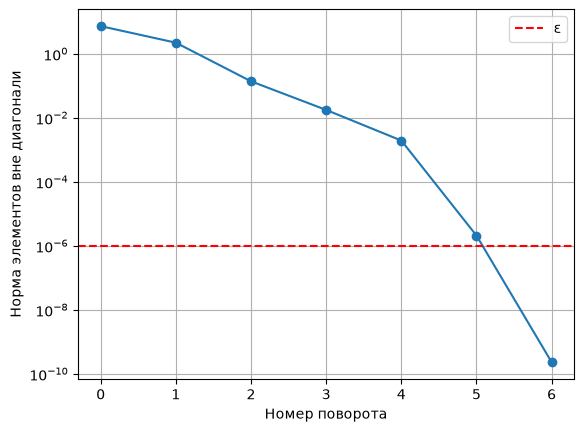

In [4]:
plt.plot([k for k, _ in history], [e for _, e in history], 'o-')
plt.axhline(eps, color='red', linestyle='--', label='ε')
plt.yscale('log')
plt.xlabel('Номер поворота')
plt.ylabel('Норма элементов вне диагонали')
plt.grid(True)
plt.legend()
plt.show()

## Самопроверка

Проверь для каждого столбца V равенство Av=λv.

In [5]:
residuals = [np.linalg.norm(np.array(A)@np.array(vectors)[:, i] - values[i]*np.array(vectors)[:, i]) for i in range(len(values))]
assert max(residuals) < 1e-5
print('Невязки собственных пар:', residuals)

Невязки собственных пар: [np.float64(2.3333976085287735e-10), np.float64(9.682678848994769e-16), np.float64(2.3333922046495386e-10)]
